In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress
import glob
from datetime import datetime
import matplotlib.cm as cm
import matplotlib.colors as mcolors
valid_combinations = [
    (1, 1), (1, 2), (1, 1000),  # r1i1p1f1, r1i2p1f1, r1i1000p1f1
    (2, 1),                     # r2i1p1f1
    (3, 1),                     # r3i1p1f1
    (4, 1),                     # r4i1p1f1
    (5, 1),                     # r5i1p1f1
    (6, 1),                     # r6i1p1f1
    (7, 1),                     # r7i1p1f1
    (8, 1),                     # r8i1p1f1
    (9, 1),                     # r9i1p1f1
    (10, 1)                     # r10i1p1f1
]

# Generate file paths only for valid combinations
files_historical = [
    f'D:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_historical_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations
]
file_SSP119 = [f'D:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp119_r{i}i1p1f1_g025.nc'for i in range(1, 6)]
files_SSP126 = [f'D:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp126_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
#missingi3
files_SSP245 = [f'D:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp245_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
files_SSP370 = [f'D:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp370_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
# file_SSP434 = 'D:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp434_r1i1p1f1_g025.nc'
file_SSP460 = 'D:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp460_r1i1p1f1_g025.nc'
file_SSP534 = 'D:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp534-over_r1i1p1f1_g025.nc'
valid_combinations_ssp585 = [
    (1, 1), (1, 2),  # r1i1p1f1, r1i2p1f1
    (2, 1),          # r2i1p1f1
    (3, 1),          # r3i1p1f1
    (4, 1),          # r4i1p1f1
    (5, 1)           # r5i1p1f1
]

# Generate file paths only for the valid combinations
files_SSP585 = [
    f'D:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp585_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations_ssp585
]

# Function to load datasets from a list of file paths
# def load_datasets(file_list):
#     datasets = []
#     for file in file_list:
#         try:
#             ds = xr.open_dataset(file)
#             datasets.append(ds)
#         except Exception as e:
#             print(f"Error loading {file}: {e}")
#     return datasets
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

# Load datasets
datasets_historical = load_datasets(files_historical)
datasets_SSP119 = load_datasets(file_SSP119)
datasets_SSP126 = load_datasets(files_SSP126)
datasets_SSP245 = load_datasets(files_SSP245)
datasets_SSP370 = load_datasets(files_SSP370)
# dataset_SSP434 = xr.open_mfdataset(file_SSP434, combine='by_coords', engine='netcdf4')
datasets_SSP460 = xr.open_mfdataset(file_SSP460, combine='by_coords', engine='netcdf4')
datasets_SSP534 = xr.open_mfdataset(file_SSP534, combine='by_coords', engine='netcdf4')
datasets_SSP585 = load_datasets(files_SSP585)

print("Datasets successfully loaded!")

Datasets successfully loaded!


In [2]:
# Function to concatenate ensemble members
def concatenate_ensemble(datasets_list):
    """Concatenates a list of xarray datasets along the 'ensemble' dimension."""
    return xr.concat(datasets_list, dim="ensemble")

# Concatenating historical datasets
datasets_historical = concatenate_ensemble(datasets_historical)

# Concatenating SSP datasets
datasets_SSP119 = concatenate_ensemble(datasets_SSP119)
datasets_SSP126 = concatenate_ensemble(datasets_SSP126)
datasets_SSP245 = concatenate_ensemble(datasets_SSP245)
datasets_SSP370 = concatenate_ensemble(datasets_SSP370)
datasets_SSP585 = concatenate_ensemble(datasets_SSP585)

# Wrapping single scenario datasets into lists before concatenation
datasets_SSP460 = [datasets_SSP460]  # Wrap it in a list to match other datasets
datasets_SSP534 = [datasets_SSP534]  # Wrap it in a list to match other datasets

# Concatenate SSP460 and SSP534 as well
datasets_SSP460 = concatenate_ensemble(datasets_SSP460)
datasets_SSP534 = concatenate_ensemble(datasets_SSP534)

print("Datasets successfully concatenated along the 'ensemble' dimension!")


Datasets successfully concatenated along the 'ensemble' dimension!


In [3]:
# Group datasets and labels
datasets_all_scenarios = [
    datasets_historical,
    datasets_SSP119,
    datasets_SSP126,
    datasets_SSP245,
    datasets_SSP370,
    # [dataset_SSP434] +
    [datasets_SSP460],
    [datasets_SSP534],
    datasets_SSP585
]

labels_all_scenarios = (
    ['Historical to Present (1850-2015)'] +
    ['SSP1-1.9 ("Very Low Emissions")'] +  
    ['SSP1-2.6 ("Low Emissions with Strong Mitigation")'] +
    ['SSP2-4.5 ("Middle of the Road")'] +
    ['SSP3-7.0 ("Regional Rivalry")'] +
    ['SSP4-6.0 ("Inequality and Regional Development")'] +  # Added SSP4-6.0
    ['SSP5-3.4 ("Fossil-Fueled Development with Delayed Climate Action")'] +
    ['SSP5-3.4-over ("Delayed Climate Action - Overshoot")'] +  # Added SSP5-3.4-over
    ['SSP5-8.5 ("Fossil-Fueled Development with No Climate Action")']
)

In [4]:
# Latitude and longitude range for Thailand (adjust as needed based on data)
thailand_lat_range = slice(5.5, 20.5)  # Latitude range for Thailand (from 20.5°N to 5.5°N)
thailand_lon_range = slice(97.5, 105.5)  # Longitude range for Thailand (from 97.5°E to 105.5°E)

In [5]:
datasets_thailand = [
    ds.sel(lat=thailand_lat_range, lon=thailand_lon_range) for ds in datasets_all_scenarios if isinstance(ds, xr.Dataset)
]


In [6]:
# Define Earth's radius in meters
R = 6378137

# Latitude and longitude arrays (in degrees)
lon = datasets_historical.coords['lon']
lat = datasets_historical.coords['lat']

# Convert to radians
lon_radians = np.radians(lon)
lat_radians = np.radians(lat)

# Calculate the differences in longitude and latitude
delta_lon = np.diff(lon_radians)[0]  # Assuming regular grid
delta_lat = np.diff(lat_radians).mean()  # Take the mean for approximate spacing

# Calculate area for each grid cell
area = np.zeros((len(lat), len(lon)))  # Initialize area array to match full grid

for i in range(len(lat)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    elif i == len(lat) - 1:  # Northernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    else:  # Interior latitudes
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2

    # Calculate area for this latitude band
    area[i, :] = (R**2 * delta_lon * (np.sin(phi2) - np.sin(phi1)))

# Convert to square kilometers
area_km2 = area / 1e6

# Print or save the area array
print("Area array (in km^2):", area_km2)
print("Shape of area array:", area_km2.shape)


Area array (in km^2): [[1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 ...
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]]
Shape of area array: (72, 144)


In [7]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat = 72  # Number of latitude points
num_lon = 144  # Number of longitude points
lat = np.linspace(-88.75, 88.75, num_lat)  # Correct number of points
lon = np.linspace(1.25, 358.75, num_lon)  # Correct number of points

# Create the DataArray
areacella = xr.DataArray(
    area_km2,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella = xr.Dataset({"area": areacella})

# Inspect the Dataset
print(areacella)

areacella_th=areacella.sel(lat=thailand_lat_range, lon=thailand_lon_range)

<xarray.Dataset> Size: 85kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 83kB 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03


In [8]:
# Define a function to process and compute ensemble statistics
def process_ssp_data_th(ssp_data, lat_range, lon_range, area_weights):
    """
    Process a pre-concatenated dataset for the Thailand region.
    Computes ensemble mean and standard deviation.
    
    Parameters:
        ssp_data (xr.Dataset): Already concatenated dataset
        lat_range (slice): Latitude range for selection
        lon_range (slice): Longitude range for selection
        area_weights (xr.DataArray): Area weights for weighted mean
    
    Returns:
        ensemble_mean (xr.DataArray): Weighted ensemble mean
        ensemble_std (xr.DataArray): Weighted ensemble standard deviation
    """
    # Select the Thailand region based on latitude and longitude ranges
    ssp_data_th = ssp_data.sel(lat=lat_range, lon=lon_range)
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std


In [9]:
# Define a function to process and compute ensemble statistics
def process_ssp_data(ssp_data, area_weights):
    """
    Process a pre-concatenated dataset for the Thailand region.
    Computes ensemble mean and standard deviation.
    
    Parameters:
        ssp_data (xr.Dataset): Already concatenated dataset
        lat_range (slice): Latitude range for selection
        lon_range (slice): Longitude range for selection
        area_weights (xr.DataArray): Area weights for weighted mean
    
    Returns:
        ensemble_mean (xr.DataArray): Weighted ensemble mean
        ensemble_std (xr.DataArray): Weighted ensemble standard deviation
    """
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std


In [10]:
historical_mean_th, historical_std_th = process_ssp_data_th(datasets_historical, thailand_lat_range, thailand_lon_range, areacella_th)
ssp119_mean_th, ssp119_std_th = process_ssp_data_th(datasets_SSP119, thailand_lat_range, thailand_lon_range, areacella_th)
ssp126_mean_th, ssp126_std_th = process_ssp_data_th(datasets_SSP126, thailand_lat_range, thailand_lon_range, areacella_th)
ssp245_mean_th, ssp245_std_th = process_ssp_data_th(datasets_SSP245, thailand_lat_range, thailand_lon_range, areacella_th)
ssp370_mean_th, ssp370_std_th = process_ssp_data_th(datasets_SSP370, thailand_lat_range, thailand_lon_range, areacella_th)
ssp460_mean_th, ssp460_std_th = process_ssp_data_th(datasets_SSP460, thailand_lat_range, thailand_lon_range, areacella_th)
ssp534_mean_th, ssp534_std_th = process_ssp_data_th(datasets_SSP534, thailand_lat_range, thailand_lon_range, areacella_th)
ssp585_mean_th, ssp585_std_th = process_ssp_data_th(datasets_SSP585, thailand_lat_range, thailand_lon_range, areacella_th)

In [11]:
historical_mean, historical_std = process_ssp_data(datasets_historical, areacella)
ssp119_mean, ssp119_std = process_ssp_data(datasets_SSP119, areacella)
ssp126_mean, ssp126_std = process_ssp_data(datasets_SSP126, areacella)
ssp245_mean, ssp245_std = process_ssp_data(datasets_SSP245, areacella)
ssp370_mean, ssp370_std = process_ssp_data(datasets_SSP370, areacella)
ssp460_mean, ssp460_std = process_ssp_data(datasets_SSP460, areacella)
ssp534_mean, ssp534_std = process_ssp_data(datasets_SSP534, areacella)
ssp585_mean, ssp585_std = process_ssp_data(datasets_SSP585, areacella)


In [12]:
historical_mean, historical_std = process_ssp_data(datasets_historical, areacella)
ensemble_means_all_scenarios = [
    historical_mean, ssp119_mean, ssp126_mean, ssp245_mean,
     ssp370_mean, ssp460_mean, ssp534_mean, ssp585_mean
]
ensemble_stds_all_scenarios = [
    historical_std, ssp119_std, ssp126_std, ssp245_std,
    ssp370_std, ssp460_std, ssp534_std, ssp585_std
]

In [13]:
# Example input (replace with your actual data)
ensemble_means_th_all_scenarios = [
    historical_mean_th, ssp119_mean_th, ssp126_mean_th, ssp245_mean_th,
     ssp370_mean_th, ssp460_mean_th, ssp534_mean_th, ssp585_mean_th
]
ensemble_stds_th_all_scenarios = [
    historical_std_th, ssp119_std_th, ssp126_std_th, ssp245_std_th,
    ssp370_std_th, ssp460_std_th, ssp534_std_th, ssp585_std_th
]

In [14]:
def plot_frp_trends_dot(datasets, ensemble_means, title, seasonal_coeffs, window_size=10):
    """ 
    Plot FRP trends over time for given datasets with ensemble mean using season-specific coefficients.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        title (str): Title for the plot.
        seasonal_coeffs (dict): Dictionary with season names as keys and (C, D) tuples as values.
        window_size (int): Window size for moving average smoothing.
    """
    def moving_average(data, window_size):
        return data.rolling(time=window_size, center=True).mean()
    
    seasons = ["Cool-Dry", "Rainy", "Warm-Dry"]
    season_styles = {"Cool-Dry": "--", "Rainy": "-", "Warm-Dry": "-."}  # Assign different line styles to seasons
    base_colors = [
        'black',  
        'navy',       
        'darkblue',  
        'green',      
        'forestgreen', 
        'red',        
        'purple',    
        'orange',    
        'gold'        
    ]
    scenario_labels = ['Historical', 'SSP119', 'SSP126', 'SSP245', 'SSP370', 'SSP434', 'SSP460', 'SSP534', 'SSP585']
    line_width = 2  # Set uniform line width
    markers = {
        "Historical": "o", "SSP119": "s", "SSP126": "^", "SSP245": "D",
        "SSP370": "s", "SSP434": "^", "SSP460": "D", "SSP534": "X", "SSP585": "X"
    }
    marker_spacing = 50  # Increase spacing to avoid clutter
    
    plt.figure(figsize=(14, 8))  # Single plot for all seasons
    
    for season in seasons:
        C, D = seasonal_coeffs[season]  # Extract coefficients for the season
        line_style = season_styles[season]  # Get line style for season
        
        # Plot individual datasets in a lighter color
        for dataset in datasets[:0]:  # Reduce dataset count for clarity
            time = dataset.coords.get('time', None)
            if time is not None and 'fwisa' in dataset:
                spatial_mean_fwi = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
                spatial_mean_frp = 10**(C * spatial_mean_fwi + D)  # Convert FWI to FRP
                smoothed_frp = moving_average(spatial_mean_frp, window_size)
                plt.plot(time, smoothed_frp, color="gray", linestyle=line_style, alpha=0.3)  # Adjust style per season
        
        # Plot ensemble means with unique colors and seasonal styles
        for ensemble_mean, label, color in zip(ensemble_means, scenario_labels, base_colors):
            if isinstance(ensemble_mean, xr.Dataset):
                ensemble_mean = ensemble_mean['fwisa']

            time = ensemble_mean.coords.get('time', None)
            if time is not None:
                marker = markers[label]
                ensemble_mean_frp = 10**(C * ensemble_mean + D)
                smoothed_frp = moving_average(ensemble_mean_frp, window_size)
                plt.plot(time, smoothed_frp, color=color, linestyle=line_style, linewidth=line_width, 
                         marker=marker, markevery=marker_spacing, label=f'Ensemble Mean ({label}, {season})')
    
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Radiative Power (FRP)', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

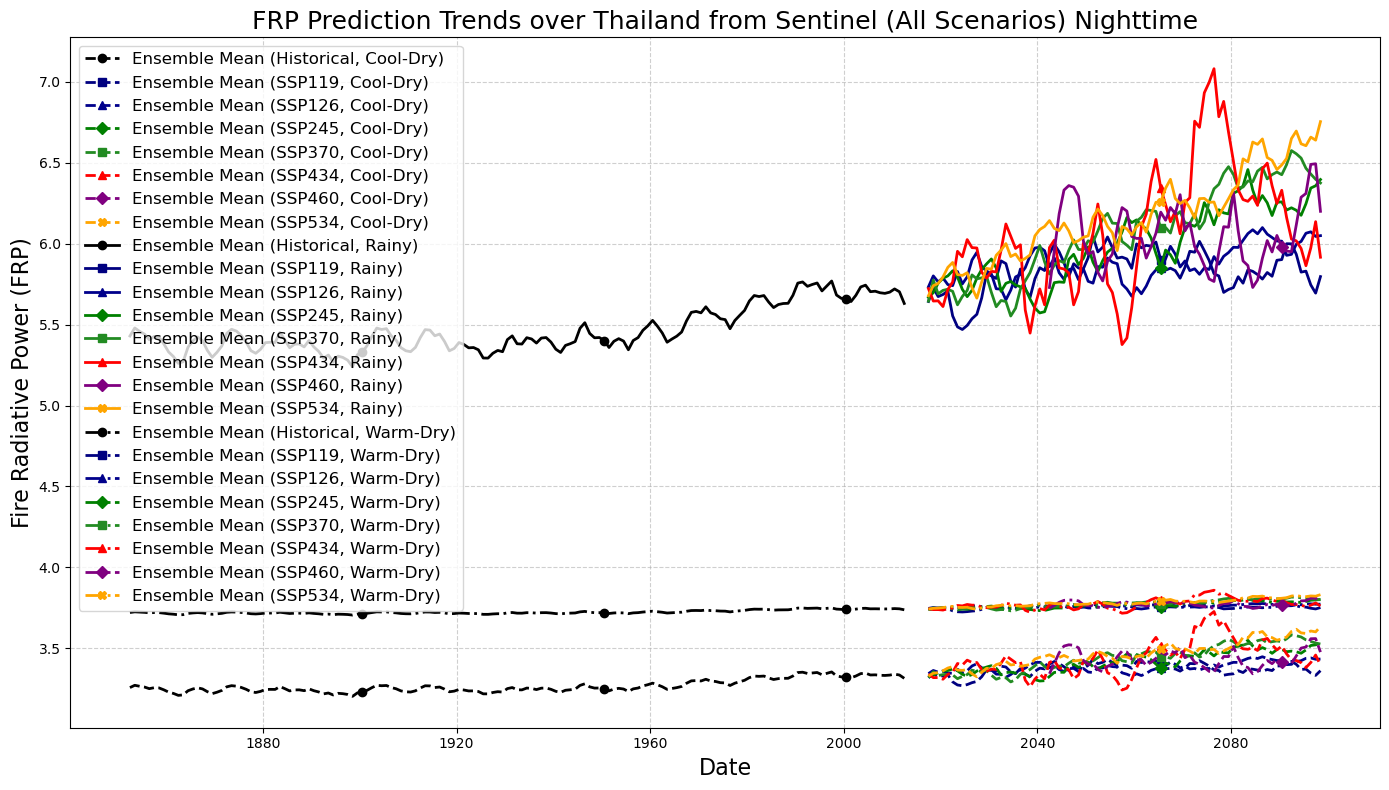

C:\Users\asus\anaconda3\envs\wildfire_env\lib\site-packages\dask\_task_spec.py:741: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
C:\Users\asus\anaconda3\envs\wildfire_env\lib\site-packages\dask\_task_spec.py:741: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
C:\Users\asus\anaconda3\envs\wildfire_env\lib\site-packages\dask\_task_spec.py:741: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
C:\Users\asus\anaconda3\envs\wildfire_env\lib\site-packages\dask\_task_spec.py:741: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
C:\Users\asus\anaconda3\envs\wildfire_env\lib\site-packages\dask\_task_spec.py:741: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
C:\Users\asus\anaconda3\envs\wildfire_env\lib\site-packages\dask\_task_spec.py:741: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
C:\Users\asus\anaconda

In [15]:
def plot_frp_trends_dot_linear(datasets, ensemble_means, title, seasonal_coeffs, window_size=10):
    """ 
    Plot FRP trends over time for given datasets with ensemble mean using season-specific coefficients.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        title (str): Title for the plot.
        seasonal_coeffs (dict): Dictionary with season names as keys and (C, D) tuples as values.
        window_size (int): Window size for moving average smoothing.
    """
    def moving_average(data, window_size):
        return data.rolling(time=window_size, center=True).mean()
    
    seasons = ["Cool-Dry", "Rainy", "Warm-Dry"]
    season_styles = {"Cool-Dry": "--", "Rainy": "-", "Warm-Dry": "-."}  # Assign different line styles to seasons
    base_colors = [
        'black',  
        'navy',       
        'darkblue',  
        'green',      
        'forestgreen', 
        'red',        
        'purple',    
        'orange',    
        'gold'        
    ]
    scenario_labels = ['Historical', 'SSP119', 'SSP126', 'SSP245', 'SSP370', 'SSP434', 'SSP460', 'SSP534', 'SSP585']
    line_width = 2  # Set uniform line width
    markers = {
        "Historical": "o", "SSP119": "s", "SSP126": "^", "SSP245": "D",
        "SSP370": "s", "SSP434": "^", "SSP460": "D", "SSP534": "X", "SSP585": "X"
    }
    marker_spacing = 50  # Increase spacing to avoid clutter
    
    plt.figure(figsize=(14, 8))  # Single plot for all seasons
    
    for season in seasons:
        C, D = seasonal_coeffs[season]  # Extract coefficients for the season
        line_style = season_styles[season]  # Get line style for season
        
        # Plot individual datasets in a lighter color
        for dataset in datasets[:0]:  # Reduce dataset count for clarity
            time = dataset.coords.get('time', None)
            if time is not None and 'fwisa' in dataset:
                spatial_mean_fwi = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
                spatial_mean_frp = C * spatial_mean_fwi + D  # Convert FWI to FRP
                smoothed_frp = moving_average(spatial_mean_frp, window_size)
                plt.plot(time, smoothed_frp, color="gray", linestyle=line_style, alpha=0.3)  # Adjust style per season
        
        # Plot ensemble means with unique colors and seasonal styles
        for ensemble_mean, label, color in zip(ensemble_means, scenario_labels, base_colors):
            if isinstance(ensemble_mean, xr.Dataset):
                ensemble_mean = ensemble_mean['fwisa']

            time = ensemble_mean.coords.get('time', None)
            if time is not None:
                marker = markers[label]
                ensemble_mean_frp = C * ensemble_mean + D
                smoothed_frp = moving_average(ensemble_mean_frp, window_size)
                plt.plot(time, smoothed_frp, color=color, linestyle=line_style, linewidth=line_width, 
                         marker=marker, markevery=marker_spacing, label=f'Ensemble Mean ({label}, {season})')
    
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Radiative Power (FRP)', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
seasonal_coefficients_frp_10years = {
    'Warm-Dry': (0.0099, 3.4695),
    'Rainy': (0.1188, 2.4126),
    'Cool-Dry': (0.0338, 2.3986)
}

plot_frp_trends_dot_linear(
    datasets_thailand, 
    ensemble_means_th_all_scenarios, 
    'FRP Prediction Trends over Thailand from Sentinel (All Scenarios) Nighttime',
    seasonal_coefficients_frp_10years,
    window_size=5
)

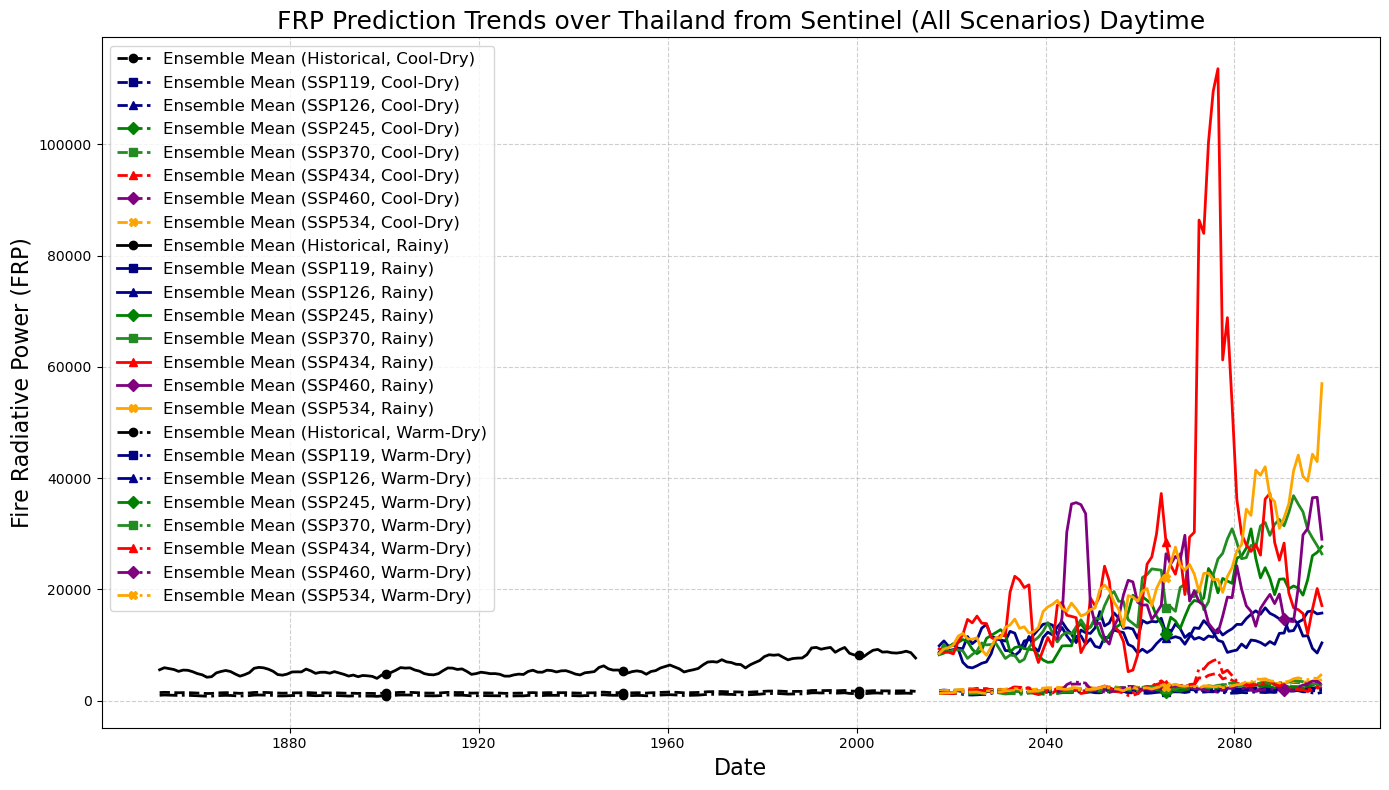

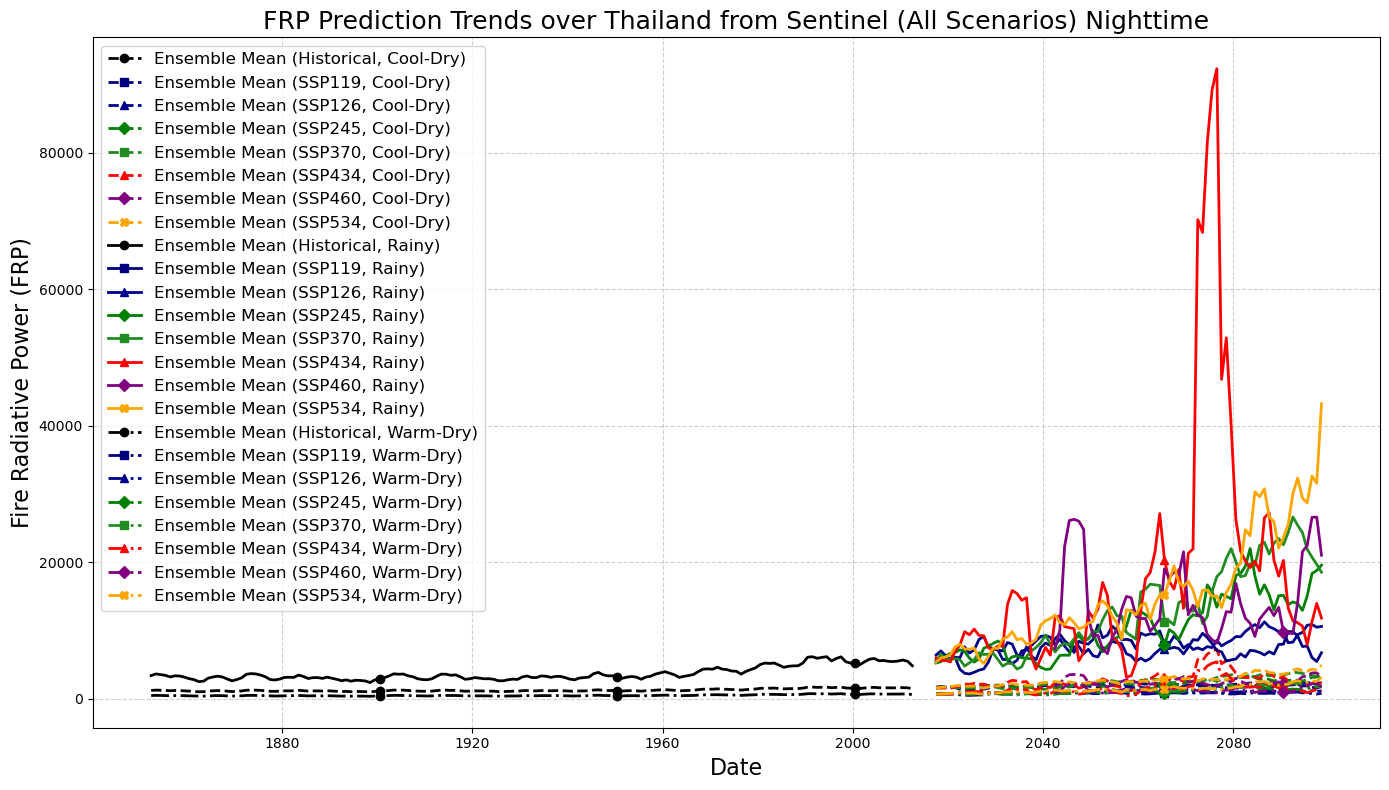

In [16]:
# Plot the FWI trends over time for all scenarios with ensemble means and boundaries
# **Define seasonal coefficients**
seasonal_coefficients_frpDAY = {
    'Warm-Dry': (0.0599, 1.4524),
    'Rainy': (0.0854, 1.5648),
    'Cool-Dry': (0.0369, 2.2171)
}

seasonal_coefficients_frpNight = {
    'Warm-Dry': (0.0686, 0.9521),
    'Rainy': (0.0924, 1.1772),
    'Cool-Dry': (0.0518, 1.7766)
}


plot_frp_trends_dot(
    datasets_thailand, 
    ensemble_means_th_all_scenarios, 
    'FRP Prediction Trends over Thailand from Sentinel (All Scenarios) Daytime',
    seasonal_coefficients_frpDAY,
    window_size=5
)

plot_frp_trends_dot(
    datasets_thailand, 
    ensemble_means_th_all_scenarios, 
    'FRP Prediction Trends over Thailand from Sentinel (All Scenarios) Nighttime',
    seasonal_coefficients_frpNight,
    window_size=5
)

In [49]:
def plot_frp_trends(datasets, ensemble_means, title, coeffs, window_size=10):
    """ 
    Plot FRP trends over time for given datasets with ensemble mean using a single (C, D) coefficient pair.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        title (str): Title for the plot.
        coeffs (tuple): A single pair (C, D) for FWI to FRP conversion.
        window_size (int): Window size for moving average smoothing.
    """
    def moving_average(data, window_size):
        return data.rolling(time=window_size, center=True).mean()
    
    C, D = coeffs  # Unpack single coefficient pair

    base_colors = [
        'black',  
        'navy',       
        'darkblue',  
        'green',      
        'forestgreen', 
        'red',        
        'purple',    
        'orange',    
        'gold'        
    ]
    scenario_labels = ['Historical', 'SSP119', 'SSP126', 'SSP245', 'SSP370', 'SSP460', 'SSP534', 'SSP585']
    line_width = 2
    markers = {
        "Historical": "o", "SSP119": "s", "SSP126": "^", "SSP245": "D",
        "SSP370": "s", "SSP460": "D", "SSP534": "X", "SSP585": "X"
    }
    marker_spacing = 50  # Increase spacing to avoid clutter

    plt.figure(figsize=(14, 8))

    # Optional: Plot individual members in light gray (if you want to see spread)
    for dataset in datasets[:0]:  # Change [:0] to [:5] if you want to show some
        time = dataset.coords.get('time', None)
        if time is not None and 'fwisa' in dataset:
            spatial_mean_fwi = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
            spatial_mean_frp = C * np.exp(spatial_mean_fwi + D)
            smoothed_frp = moving_average(spatial_mean_frp, window_size)
            plt.plot(time, smoothed_frp, color="gray", linestyle="--", alpha=0.3)

    # Plot ensemble means with scenario-specific colors and markers
    for ensemble_mean, label, color in zip(ensemble_means, scenario_labels, base_colors):
        if isinstance(ensemble_mean, xr.Dataset):
            ensemble_mean = ensemble_mean['fwisa']

        time = ensemble_mean.coords.get('time', None)
        if time is not None:
            marker = markers[label]
            ensemble_mean_frp = C * np.exp(ensemble_mean + D)
            smoothed_frp = moving_average(ensemble_mean_frp, window_size)
            plt.plot(time, smoothed_frp, color=color, linewidth=line_width,
                     marker=marker, markevery=marker_spacing, label=f'Ensemble Mean ({label})')

    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Radiative Power (FRP) [MW]', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=10, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


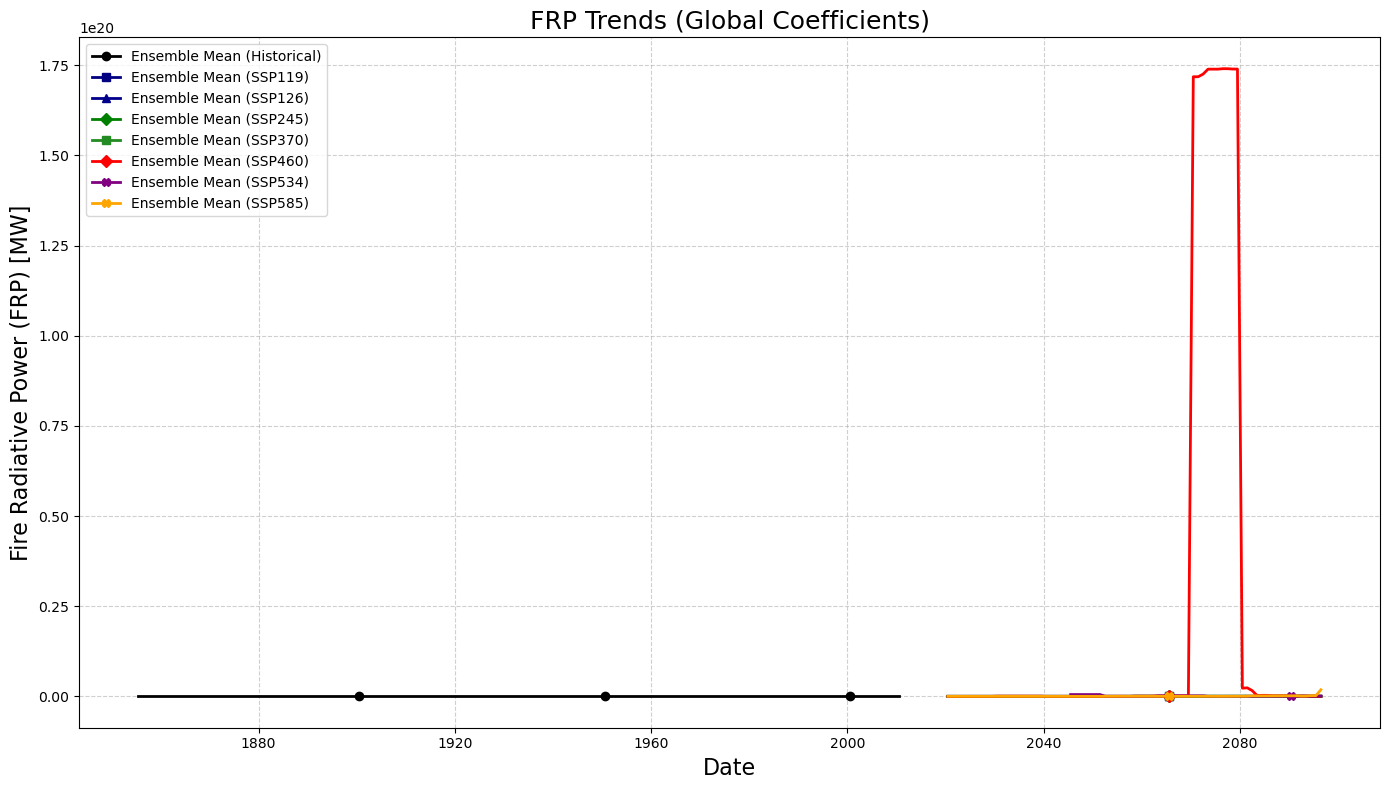

In [51]:
coeffs = (23.5048, 0.1615)  # Use your global C and D here
plot_frp_trends(datasets_thailand, 
    ensemble_means_th_all_scenarios, "FRP Trends (Global Coefficients)", coeffs)

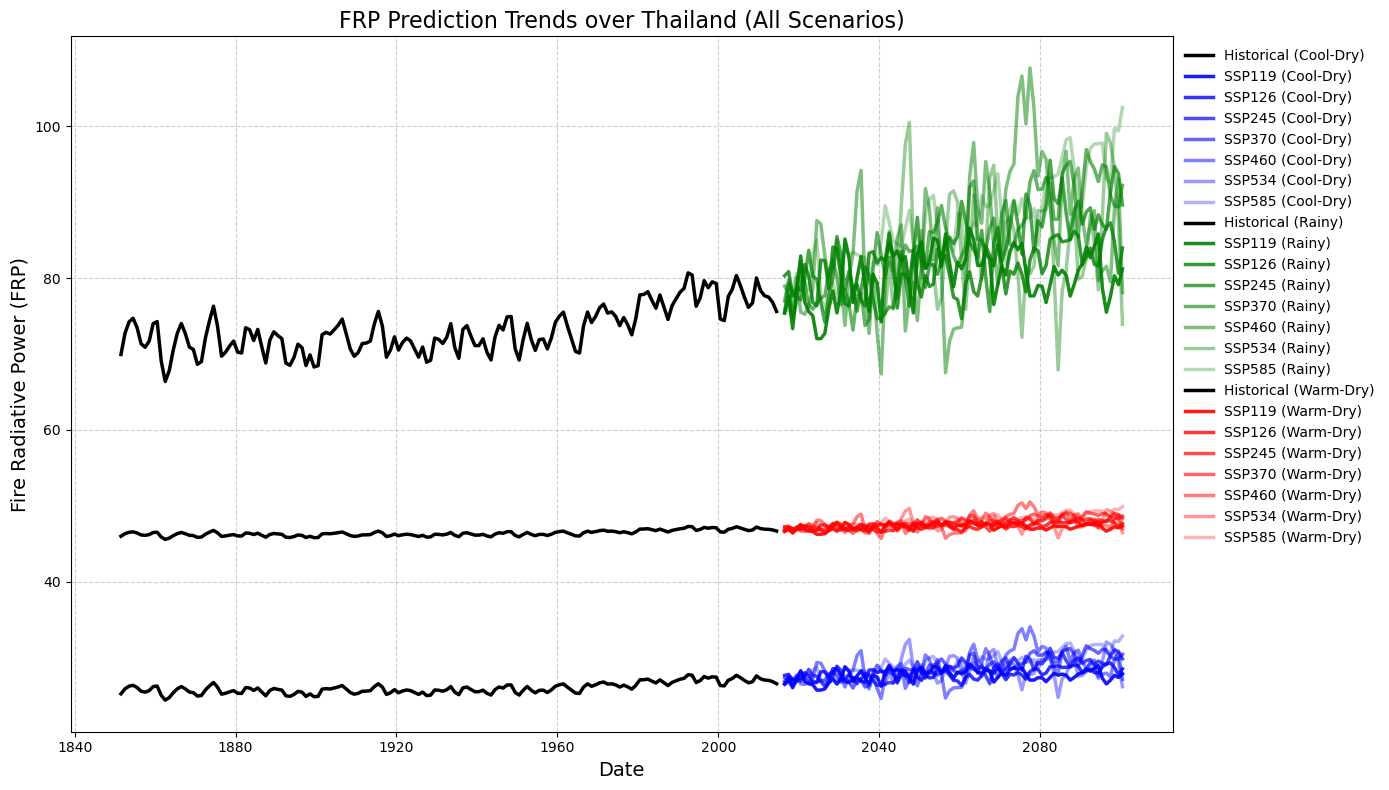

In [19]:
def plot_frp_trends_linear(datasets, ensemble_means, title, seasonal_coeffs, window_size):
    """ 
    Plot FRP trends over time for given datasets with ensemble mean using season-specific coefficients.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        title (str): Title for the plot.
        seasonal_coeffs (dict): Dictionary with season names as keys and (C, D) tuples as values.
        window_size (int): Window size for moving average smoothing.
    """
    def moving_average(data, window_size):
        return data.rolling(time=window_size, center=True).mean()
    
    seasons = ["Cool-Dry", "Rainy", "Warm-Dry"]
    base_colors = {"Cool-Dry": "blue", "Rainy": "green", "Warm-Dry": "red"}
    color_shades = {
        "Historical": "black",  # Change Historical to black
        "SSP119": 0.9,
        "SSP126": 0.8,
        "SSP245": 0.7,
        "SSP370": 0.6,
        # "SSP434": 0.5,
        "SSP460": 0.5,
        "SSP534": 0.4,
        "SSP585": 0.3
    }
    
    plt.figure(figsize=(14, 8))  # Single plot for all seasons
    
    for season in seasons:
        C, D = seasonal_coeffs[season]  # Extract coefficients for the season
        base_color = base_colors[season]
        
        # Plot individual datasets in a lighter color
        for dataset in datasets[:0]:
            time = dataset.coords.get('time', None)
            if time is not None and 'fwisa' in dataset:
                spatial_mean_fwi = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
                spatial_mean_frp = C * spatial_mean_fwi + D  # Linear transformation
                smoothed_frp = moving_average(spatial_mean_frp, window_size)
                plt.plot(time, smoothed_frp, color=mcolors.to_rgba(base_color, 0.2))
        
        # Plot ensemble means with different shades of the base color
        scenario_labels = ['Historical', 'SSP119', 'SSP126', 'SSP245', 'SSP370', 'SSP460', 'SSP534', 'SSP585']
        
        for ensemble_mean, label in zip(ensemble_means, scenario_labels):
            if isinstance(ensemble_mean, xr.Dataset):
                ensemble_mean = ensemble_mean['fwisa']

            time = ensemble_mean.coords.get('time', None)
            if time is not None:
                color_shade = "black" if label == "Historical" else mcolors.to_rgba(base_color, color_shades[label])
                ensemble_mean_frp = C * ensemble_mean + D  # Linear transformation
                smoothed_frp = moving_average(ensemble_mean_frp, window_size)
                plt.plot(time, smoothed_frp, color=color_shade, linewidth=2.5, label=f'{label} ({season})')
    
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Radiative Power (FRP)', fontsize=14)
    plt.title(title, fontsize=16)

    # Adjusting legend to be smaller and placed outside the plot
    plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1, 1), frameon=False, ncol=1)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
seasonal_coefficients_frp_10years = {
    'Warm-Dry': (0.2790, 39.2341),
    'Rainy': (2.3345, 13.2520),
    'Cool-Dry': (0.5463, 11.9846)
}

# Run the modified function
plot_frp_trends_linear(
    datasets_thailand, 
    ensemble_means_th_all_scenarios, 
    'FRP Prediction Trends over Thailand (All Scenarios)',
    seasonal_coefficients_frp_10years,
    window_size=2
)


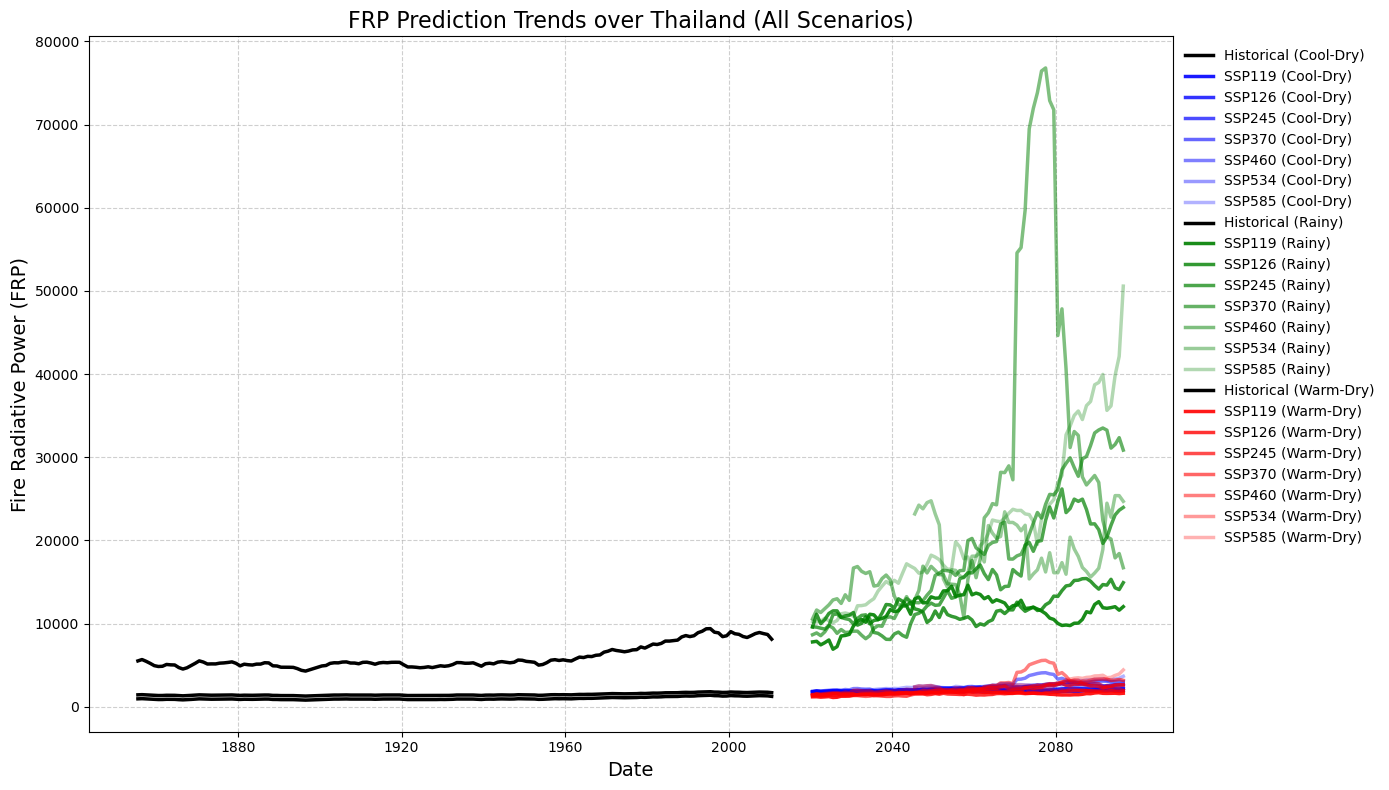

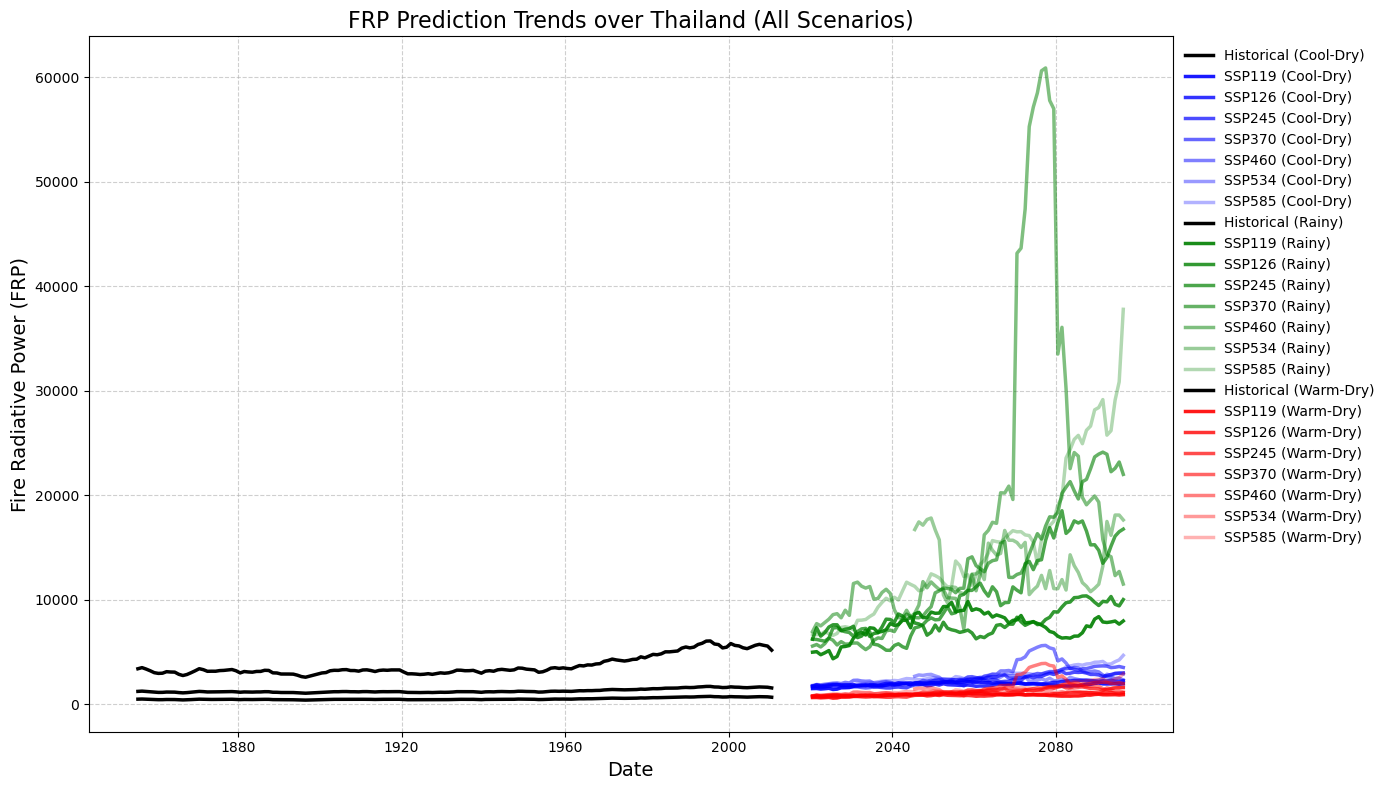

In [46]:
def plot_frp_trends_exp(datasets, ensemble_means, title, seasonal_coeffs, window_size):
    """ 
    Plot FRP trends over time for given datasets with ensemble mean using season-specific coefficients.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        title (str): Title for the plot.
        seasonal_coeffs (dict): Dictionary with season names as keys and (C, D) tuples as values.
        window_size (int): Window size for moving average smoothing.
    """
    def moving_average(data, window_size):
        return data.rolling(time=window_size, center=True).mean()
    
    seasons = ["Cool-Dry", "Rainy", "Warm-Dry"]
    base_colors = {"Cool-Dry": "blue", "Rainy": "green", "Warm-Dry": "red"}
    color_shades = {
        "Historical": "black",  # Change Historical to black
        "SSP119": 0.9,
        "SSP126": 0.8,
        "SSP245": 0.7,
        "SSP370": 0.6,
        # "SSP434": 0.5,
        "SSP460": 0.5,
        "SSP534": 0.4,
        "SSP585": 0.3
    }
    
    plt.figure(figsize=(14, 8))  # Single plot for all seasons
    
    for season in seasons:
        C, D = seasonal_coeffs[season]  # Extract coefficients for the season
        base_color = base_colors[season]
        
        # Plot individual datasets in a lighter color
        for dataset in datasets[:0]:
            time = dataset.coords.get('time', None)
            if time is not None and 'fwisa' in dataset:
                spatial_mean_fwi = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
                spatial_mean_frp = 10**(C * spatial_mean_fwi + D)  # Linear transformation
                smoothed_frp = moving_average(spatial_mean_frp, window_size)
                plt.plot(time, smoothed_frp, color=mcolors.to_rgba(base_color, 0.2))
        
        # Plot ensemble means with different shades of the base color
        scenario_labels = ['Historical', 'SSP119', 'SSP126', 'SSP245', 'SSP370', 'SSP460', 'SSP534', 'SSP585']
        
        for ensemble_mean, label in zip(ensemble_means, scenario_labels):
            if isinstance(ensemble_mean, xr.Dataset):
                ensemble_mean = ensemble_mean['fwisa']

            time = ensemble_mean.coords.get('time', None)
            if time is not None:
                color_shade = "black" if label == "Historical" else mcolors.to_rgba(base_color, color_shades[label])
                ensemble_mean_frp = 10**(C * ensemble_mean + D)  # Linear transformation
                smoothed_frp = moving_average(ensemble_mean_frp, window_size)
                plt.plot(time, smoothed_frp, color=color_shade, linewidth=2.5, label=f'{label} ({season})')
    
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Radiative Power (FRP)', fontsize=14)
    plt.title(title, fontsize=16)

    # Adjusting legend to be smaller and placed outside the plot
    plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1, 1), frameon=False, ncol=1)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
plot_frp_trends_exp(
    datasets_thailand, 
    ensemble_means_th_all_scenarios, 
    'FRP Prediction Trends over Thailand (All Scenarios)',
    seasonal_coefficients_frpDAY,
    window_size=10
)

plot_frp_trends_exp(
    datasets_thailand, 
    ensemble_means_th_all_scenarios, 
    'FRP Prediction Trends over Thailand (All Scenarios)',
    seasonal_coefficients_frpNight,
    window_size=10
)